In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

In [2]:
directory = "../extracted_waldo"  
all_data = []
file_count = 0
max_files = 15  
for filename in sorted(os.listdir(directory)):
    if filename.endswith(".txt"):
        file_count += 1
        if file_count > max_files:
            break  # Stop after loading 15 files
        file_path = os.path.join(directory, filename)
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            numeric_data = [line.strip().split() for line in lines if not line.startswith("MSG")]
            if numeric_data:
                df = pd.DataFrame(numeric_data)
                first_row_cols = len(df.iloc[0])
                df.columns = [f"col_{i}" for i in range(first_row_cols)]
                df = df.apply(pd.to_numeric, errors='coerce')
                all_data.append(df)

print(f"Total files loaded: {len(all_data)}")
for i, df in enumerate(all_data):
    print(f"File {i+1}: Shape = {df.shape}")
print("\nFirst 5 rows of first dataset:")
print(all_data[0].head())

# Initialize lists for data processing
time = []
x_left = []
y_left = []
pupil_size_left = []
x_right = []
y_right = []
pupil_size_right = []
category_left = []
category_right = []
fixation = []
saccade = []
velocity_left = []
velocity_right = []
acceleration_left = []
acceleration_right = []
filtered_x_left = []
filtered_y_left = []
filtered_x_right = []
filtered_y_right = []
filtered_time = []
filtered_saccade = []
filtered_fixation = []
filtered_category_left = []
filtered_category_right = []
remove_nanbefore = 500
# Process each dataset
for i in range(len(all_data)):
    arr = np.swapaxes(np.array(all_data[i]), 0, 1)
    time.append(arr[0])
    x_left.append(arr[1])
    y_left.append(arr[2])
    pupil_size_left.append(arr[3])
    x_right.append(arr[4])
    y_right.append(arr[5])
    pupil_size_right.append(arr[6])
    category_left.append(arr[8])
    category_right.append(arr[9])
    fixation.append(np.where(category_left[-1] == 1, 1, 0))
    saccade.append(np.where(category_left[-1] == 2, 1, 0))
    Nan_array = (np.logical_not(np.isnan(x_left[-1])) & 
                 np.logical_not(np.isnan(y_left[-1])) &
                 np.logical_not(np.isnan(x_right[-1])) & 
                 np.logical_not(np.isnan(y_right[-1])))
    new_nan_array = Nan_array.copy()
    for j in range(1, remove_nanbefore):
        if j < len(new_nan_array):
            new_nan_array[:-j] *= Nan_array[j:]
    Nan_array = new_nan_array
    for j in range(1, remove_nanbefore):
        if j < len(new_nan_array):
            new_nan_array[j:] *= Nan_array[:-j]
    Nan_array = new_nan_array
    valid_indices = np.where(Nan_array)[0]  # Note: removed [:-1] as it was inconsistent
    filtered_x_left.append(x_left[-1][valid_indices])
    filtered_y_left.append(y_left[-1][valid_indices])
    filtered_x_right.append(x_right[-1][valid_indices])
    filtered_y_right.append(y_right[-1][valid_indices])
    filtered_time.append(time[-1][valid_indices])
    filtered_category_left.append(category_left[-1][valid_indices])
    filtered_category_right.append(category_right[-1][valid_indices])
    filtered_saccade.append(saccade[-1][valid_indices])
    filtered_fixation.append(fixation[-1][valid_indices])
    dt = 1/1000
    delta_xpl = np.diff(x_left[-1])
    delta_ypl = np.diff(y_left[-1])
    delta_xpr = np.diff(x_right[-1])
    delta_ypr = np.diff(y_right[-1])
    distances_left = np.sqrt(delta_xpl**2 + delta_ypl**2)
    distances_right = np.sqrt(delta_xpr**2 + delta_ypr**2)
    v_left = distances_left / dt
    v_right = distances_right / dt
    velocity_left.append(v_left)
    velocity_right.append(v_right)
    a_left = np.diff(v_left) / dt
    a_right = np.diff(v_right) / dt
    acceleration_left.append(a_left)
    acceleration_right.append(a_right)
filtered_category_right = np.concatenate(filtered_category_right)
filtered_x_right = np.concatenate(filtered_x_right)
filtered_y_right = np.concatenate(filtered_y_right)
filtered_category_left = np.concatenate(filtered_category_left)
filtered_x_left = np.concatenate(filtered_x_left)
filtered_y_left = np.concatenate(filtered_y_left)
filtered_saccade = np.concatenate(filtered_saccade)
filtered_fixation = np.concatenate(filtered_fixation)
filtered_time = np.concatenate(filtered_time)
common_fix_indices = np.where((filtered_category_left == 1) & (filtered_category_right == 1))[0]
common_x_fix_left = filtered_x_left[common_fix_indices]
common_x_fix_right = filtered_x_right[common_fix_indices]
common_y_fix_left = filtered_y_left[common_fix_indices]
common_y_fix_right = filtered_y_right[common_fix_indices]
common_fixation_count = len(common_fix_indices)
if common_fixation_count > 0:
    fix_x_y_left_corr = np.corrcoef(common_x_fix_left, common_y_fix_left)[0, 1]
    fix_x_y_right_corr = np.corrcoef(common_x_fix_right, common_y_fix_right)[0, 1]
else:
    fix_x_y_left_corr = 0
    fix_x_y_right_corr = 0
common_sac_indices = np.where((filtered_category_left == 2) & (filtered_category_right == 2))[0]
common_x_sac_left = filtered_x_left[common_sac_indices]
common_x_sac_right = filtered_x_right[common_sac_indices]
common_y_sac_left = filtered_y_left[common_sac_indices]
common_y_sac_right = filtered_y_right[common_sac_indices]
common_saccade_count = len(common_sac_indices)
if common_saccade_count > 0:
    sac_x_y_left_corr = np.corrcoef(common_x_sac_left, common_y_sac_left)[0, 1]
    sac_x_y_right_corr = np.corrcoef(common_x_sac_right, common_y_sac_right)[0, 1]
else:
    sac_x_y_left_corr = 0
    sac_x_y_right_corr = 0

Total files loaded: 15
File 1: Shape = (405103, 10)
File 2: Shape = (405090, 10)
File 3: Shape = (405106, 10)
File 4: Shape = (405120, 10)
File 5: Shape = (405191, 10)
File 6: Shape = (405150, 10)
File 7: Shape = (405137, 10)
File 8: Shape = (405088, 10)
File 9: Shape = (405138, 10)
File 10: Shape = (405147, 10)
File 11: Shape = (405127, 10)
File 12: Shape = (405103, 10)
File 13: Shape = (405093, 10)
File 14: Shape = (405128, 10)
File 15: Shape = (405163, 10)

First 5 rows of first dataset:
         col_0  col_1  col_2  col_3  col_4  col_5  col_6  col_7  col_8  col_9
0  688355663.0  685.4  606.2  652.0  662.8  583.2  689.0    0.0    0.0    0.0
1  688355664.0  683.3  605.3  653.0  661.2  581.6  690.0    0.0    0.0    0.0
2  688355665.0  682.2  604.4  654.0  659.3  579.6  690.0    0.0    0.0    0.0
3  688355666.0  682.0  604.1  653.0  658.5  579.1  690.0    0.0    0.0    1.0
4  688355667.0  681.8  603.2  653.0  658.1  578.6  690.0    0.0    0.0    1.0


In [3]:
dx = np.diff(filtered_x_left)
dy = np.diff(filtered_y_left)
dt = np.diff(filtered_time)
dt = np.where(dt == 0, 1e-6, dt)  
point_disp = np.sqrt(dx**2 + dy**2)
point_velo = point_disp / dt
theta_np = []
for i in range(len(dx) - 1):
    vec1 = [dx[i], dy[i]]
    vec2 = [dx[i + 1], dy[i + 1]]
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        theta_np.append(np.nan)
        continue
    unit1 = vec1 / norm1
    unit2 = vec2 / norm2
    dot_product = np.dot(unit1, unit2)
    dot_product = np.clip(dot_product, -1.0, 1.0)
    theta = np.abs(np.arccos(dot_product))
    theta_np.append(theta)
theta_np = np.array(theta_np)
valid_theta_indices = ~np.isnan(theta_np)
theta_np = theta_np[valid_theta_indices]
point_velo_eff = np.abs(point_velo[:-1][valid_theta_indices] * np.cos(theta_np))
x_val_corr = filtered_x_left[1:-1][valid_theta_indices]  
y_val_corr = filtered_y_left[1:-1][valid_theta_indices]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
def apply_idt(x_vals, y_vals, timestamps, x_threshold=25, y_threshold=25, dur_threshold=0.150):
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    temp_x_fix, temp_y_fix = [], []
    temp_timestamps = []
    s_point = 0
    for i in range(len(x_vals)):
        if i < s_point:
            continue
        temp_x_fix.append(x_vals[i])
        temp_y_fix.append(y_vals[i])
        temp_timestamps.append(timestamps[i])
        max_x = max(temp_x_fix)
        min_x = min(temp_x_fix)
        max_y = max(temp_y_fix)
        min_y = min(temp_y_fix)
        if (max_x - min_x) > x_threshold or (max_y - min_y) > y_threshold:
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold and len(temp_x_fix) > 1:
                x_fix.extend(temp_x_fix[:-1])
                y_fix.extend(temp_y_fix[:-1])
                classifier.extend(["fixation"] * (len(temp_x_fix) - 1))
            else:
                x_sac.extend(temp_x_fix[:-1])
                y_sac.extend(temp_y_fix[:-1])
                classifier.extend(["saccade"] * (len(temp_x_fix) - 1))
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
            temp_x_fix = []
            temp_y_fix = []
            temp_timestamps = []
            s_point = i + 1
        if i == len(x_vals) - 1:
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold:
                x_fix.extend(temp_x_fix)
                y_fix.extend(temp_y_fix)
                classifier.extend(["fixation"] * len(temp_x_fix))
            else:
                x_sac.extend(temp_x_fix)
                y_sac.extend(temp_y_fix)
                classifier.extend(["saccade"] * len(temp_x_fix))
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}
def compute_k_ratio(classifier):
    if len(classifier) == 0:
        return float('inf')
    P = sum(1 for c in classifier if c == "saccade") / len(classifier)
    if P == 0 or P == 1:
        return float('inf')
    p_ind = len(classifier) * P * (1 - P)
    p_emp = sum(classifier[j] != classifier[j + 1] for j in range(len(classifier) - 1))
    return p_emp / p_ind if p_ind != 0 else float('inf')
# I-VT Optimization
v_min_ivt = np.percentile(point_velo, 5)
v_max_ivt = np.percentile(point_velo, 98)
num_thresholds = 200
thresholds_ivt = np.linspace(v_min_ivt, v_max_ivt, num_thresholds)
k_ratios_ivt = []
for threshold in thresholds_ivt:
    classifier = ["fixation" if v < threshold else "saccade" for v in point_velo]
    k_ratios_ivt.append(compute_k_ratio(classifier))
ivt_min_idx = np.argmin(k_ratios_ivt)
ivt_optimal_threshold = thresholds_ivt[ivt_min_idx]
# I-AVT optimization
v_min_avt = 0
v_max_avt = 24  
thresholds_avt = np.linspace(v_min_avt, v_max_avt, num_thresholds)
k_ratios_avt = []
for threshold in thresholds_avt:
    classifier = ["fixation" if v < threshold else "saccade" for v in point_velo_eff]
    k_ratios_avt.append(compute_k_ratio(classifier))
iavt_min_idx = np.argmin(k_ratios_avt)
iavt_optimal_threshold = thresholds_avt[iavt_min_idx]
x_y_thresholds = np.linspace(5, 90, 10)  # Expanded range for better optimization
dur_thresh_values = np.linspace(0.05, 0.5, 5)  
best_k_ratio = float('inf')
best_params = {'x_y_threshold': None, 'dur_threshold': None}

for xy_th in x_y_thresholds:
    for dur_th in dur_thresh_values:
        idt_temp = apply_idt(filtered_x_left, filtered_y_left, filtered_time, xy_th, xy_th, dur_th)
        k_ratio = compute_k_ratio(idt_temp['classifier'])
        if k_ratio < best_k_ratio:
            best_k_ratio = k_ratio
            best_params = {'x_y_threshold': xy_th, 'dur_threshold': dur_th}

print(f"Optimal I-DT parameters: {best_params}")
sampling_rate = 1000  
fixed_duration_samples = int(best_params['dur_threshold'] * sampling_rate)
window_size = 10
disp_values = []
for i in range(len(filtered_x_left) - window_size):
    window_x = filtered_x_left[i:i+window_size]
    window_y = filtered_y_left[i:i+window_size]
    dispersion = (max(window_x) - min(window_x)) + (max(window_y) - min(window_y))
    disp_values.append(dispersion)

disp_values = np.array(disp_values)
d_min = np.percentile(disp_values, 1)
d_max = np.percentile(disp_values, 98)
thresholds_idt = np.linspace(d_min, d_max, 50)

k_ratios_idt = []
for threshold in thresholds_idt:
    classifier = ["saccade"] * len(disp_values)
    i = 0
    sac_count = 0
    while i < len(disp_values):
        if disp_values[i] < threshold:
            start = i
            while i < len(disp_values) and disp_values[i] < threshold:
                i += 1
            end = i
            if (end - start) >= fixed_duration_samples:
                for j in range(start, end):
                    classifier[j] = "fixation"
            else:
                for j in range(start, end):
                    classifier[j] = "saccade"
                    sac_count += 1
        else:
            sac_count += 1
            i += 1
    P = sac_count / len(classifier)
    p_ind = len(classifier) * P * (1 - P)
    p_emp = sum(classifier[j] != classifier[j+1] for j in range(len(classifier) - 1))
    k_ratio = p_emp / p_ind if p_ind != 0 else float('inf')
    k_ratios_idt.append(k_ratio)

idt_min_idx = np.argmin(k_ratios_idt)
idt_optimal_disp = thresholds_idt[idt_min_idx]
print(f"Optimal dispersion for plot (fixed dur samples {fixed_duration_samples}): {idt_optimal_disp:.2f}")


Optimal I-DT parameters: {'x_y_threshold': np.float64(90.0), 'dur_threshold': np.float64(0.05)}
Optimal dispersion for plot (fixed dur samples 50): 4.29


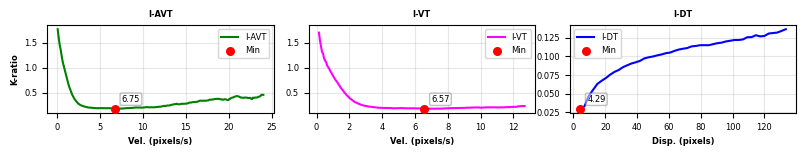

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 1.5))

# share y only between I-AVT and I-VT
ax2.sharey(ax1)

# I-AVT
ax1.plot(thresholds_avt, k_ratios_avt, c="green", linewidth=1.5, label="I-AVT")
ax1.scatter(thresholds_avt[iavt_min_idx], k_ratios_avt[iavt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax1.annotate(f"{iavt_optimal_threshold:.2f}",
             xy=(thresholds_avt[iavt_min_idx], k_ratios_avt[iavt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax1.set_xlabel("Vel. (pixels/s)", fontsize=6, fontweight='bold')
ax1.set_ylabel("K-ratio", fontsize=6, fontweight='bold')
ax1.set_title("I-AVT", fontsize=6, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=6)
ax1.tick_params(axis='both', labelsize=6)

# I-VT
ax2.plot(thresholds_ivt, k_ratios_ivt, c="magenta", linewidth=1.5, label="I-VT")
ax2.scatter(thresholds_ivt[ivt_min_idx], k_ratios_ivt[ivt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax2.annotate(f"{ivt_optimal_threshold:.2f}",
             xy=(thresholds_ivt[ivt_min_idx], k_ratios_ivt[ivt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax2.set_xlabel("Vel. (pixels/s)", fontsize=6, fontweight='bold')
ax2.set_title("I-VT", fontsize=6, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=6)
ax2.tick_params(axis='both', labelsize=6)

# I-DT (independent y-scale)
ax3.plot(thresholds_idt, k_ratios_idt, c="blue", linewidth=1.5, label="I-DT")
ax3.scatter(thresholds_idt[idt_min_idx], k_ratios_idt[idt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax3.annotate(f"{idt_optimal_disp:.2f}",
             xy=(thresholds_idt[idt_min_idx], k_ratios_idt[idt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax3.set_xlabel("Disp. (pixels)", fontsize=6, fontweight='bold')
ax3.set_title("I-DT", fontsize=6, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=6)
ax3.tick_params(axis='both', labelsize=6)

plt.tight_layout(pad=0.5)
plt.savefig("k_ratio_Waldo.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()


In [6]:
print(f"I-AVT: optimal angular velocity threshold = {iavt_optimal_threshold:.2f} rad/s, "
      f"K-ratio = {k_ratios_avt[iavt_min_idx]:.4f}")

print(f"I-VT: optimal velocity threshold = {ivt_optimal_threshold:.2f} pixels/s, "
      f"K-ratio = {k_ratios_ivt[ivt_min_idx]:.4f}")

print(f"I-DT: optimal dispersion threshold = {idt_optimal_disp:.2f} pixels, "
      f"K-ratio = {k_ratios_idt[idt_min_idx]:.4f}")


I-AVT: optimal angular velocity threshold = 6.75 rad/s, K-ratio = 0.1813
I-VT: optimal velocity threshold = 6.57 pixels/s, K-ratio = 0.1790
I-DT: optimal dispersion threshold = 4.29 pixels, K-ratio = 0.0297


In [7]:
def apply_ivt(point_velo, x_vals, y_vals, threshold):
    min_len = min(len(point_velo), len(x_vals), len(y_vals))
    point_velo = point_velo[:min_len]
    x_vals = x_vals[:min_len]
    y_vals = y_vals[:min_len]
    
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    for i in range(min_len):
        if 0 <= point_velo[i] < threshold:
            x_fix.append(x_vals[i])
            y_fix.append(y_vals[i])
            classifier.append("fixation")
        else:
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}

def apply_iavt(point_velo_eff, x_vals, y_vals, threshold):
    min_len = min(len(point_velo_eff), len(x_vals), len(y_vals))
    point_velo_eff = point_velo_eff[:min_len]
    x_vals = x_vals[:min_len]
    y_vals = y_vals[:min_len]
    
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    for i in range(min_len):
        if point_velo_eff[i] < threshold:
            x_fix.append(x_vals[i])
            y_fix.append(y_vals[i])
            classifier.append("fixation")
        else:
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}

def apply_idt(x_vals, y_vals, timestamps, x_threshold=25, y_threshold=25, dur_threshold=0.150):
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    
    temp_x_fix, temp_y_fix = [], []
    temp_timestamps = []
    
    s_point = 0
    for i in range(len(x_vals)):
        if i < s_point:
            continue
        
        temp_x_fix.append(x_vals[i])
        temp_y_fix.append(y_vals[i])
        temp_timestamps.append(timestamps[i])
        
        max_x = max(temp_x_fix)
        min_x = min(temp_x_fix)
        max_y = max(temp_y_fix)
        min_y = min(temp_y_fix)
        
        if (max_x - min_x) > x_threshold or (max_y - min_y) > y_threshold:
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold and len(temp_x_fix) > 1:
                x_fix.extend(temp_x_fix[:-1])
                y_fix.extend(temp_y_fix[:-1])
                classifier.extend(["fixation"] * (len(temp_x_fix) - 1))
            else:
                x_sac.extend(temp_x_fix[:-1])
                y_sac.extend(temp_y_fix[:-1])
                classifier.extend(["saccade"] * (len(temp_x_fix) - 1))
            
            # Current point starts new potential fixation or saccade
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
            
            temp_x_fix = []
            temp_y_fix = []
            temp_timestamps = []
            s_point = i + 1
        if i == len(x_vals) - 1:
            # Handle last group
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold:
                x_fix.extend(temp_x_fix)
                y_fix.extend(temp_y_fix)
                classifier.extend(["fixation"] * len(temp_x_fix))
            else:
                x_sac.extend(temp_x_fix)
                y_sac.extend(temp_y_fix)
                classifier.extend(["saccade"] * len(temp_x_fix))
    
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}
length_ivt = len(point_velo)
length_iavt = len(point_velo_eff)
x_ivt = filtered_x_left[:length_ivt]
y_ivt = filtered_y_left[:length_ivt]
x_iavt = x_val_corr[:length_iavt]  
y_iavt = y_val_corr[:length_iavt]

ivt_results = apply_ivt(point_velo, x_ivt, y_ivt, ivt_optimal_threshold)
iavt_results = apply_iavt(point_velo_eff, x_iavt, y_iavt, iavt_optimal_threshold)
idt_results = apply_idt(filtered_x_left, filtered_y_left, filtered_time, 
                        best_params['x_y_threshold'], best_params['x_y_threshold'], best_params['dur_threshold'])

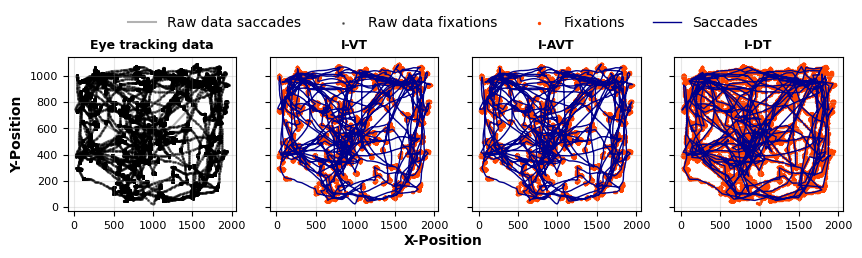

In [8]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 2), sharex=True, sharey=True)
axis_fs = 10
ax1.plot(filtered_x_left, filtered_y_left, 'k-', alpha=0.3)
ax1.scatter(filtered_x_left, filtered_y_left, s=1, c='black', alpha=0.5, marker='o')
ax1.set_ylabel("Y-Position", fontsize=axis_fs, fontweight='bold')
ax1.set_title("Eye tracking data", fontsize=9, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=8)

ax2.scatter(ivt_results['x_fix'], ivt_results['y_fix'], s=2, c="#FF4500", alpha=1, marker='o')
ax2.plot(ivt_results['x_sac'], ivt_results['y_sac'], '-', color="#00008B", linewidth=1, alpha=1)
ax2.set_title("I-VT", fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=8)

ax3.plot(iavt_results['x_sac'], iavt_results['y_sac'], '-', color="#00008B", linewidth=1, alpha=1)
ax3.scatter(iavt_results['x_fix'], iavt_results['y_fix'], s=2, c="#FF4500", alpha=1, marker='o')
ax3.set_title("I-AVT", fontsize=9, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', labelsize=8)

ax4.scatter(idt_results['x_fix'], idt_results['y_fix'], s=2, c="#FF4500", alpha=1, marker='o')
ax4.plot(idt_results['x_sac'], idt_results['y_sac'], '-', color="#00008B", linewidth=1, alpha=1)
ax4.set_title("I-DT", fontsize=9, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='both', labelsize=8)

fig.text(0.5, -0.06, 'X-Position', ha='center', fontsize=axis_fs, fontweight='bold')

fig.legend(['Raw data saccades', 'Raw data fixations', 'Fixations', 'Saccades'], 
           loc='upper center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.15), frameon=False)

plt.savefig("complete_algorithm_comparison_Waldo.png", dpi=600, bbox_inches='tight', pad_inches=0.05)
plt.show()

/tmp/ipykernel_19472/1748556477.py:88: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df = pd.concat([summary_df, pd.DataFrame([{


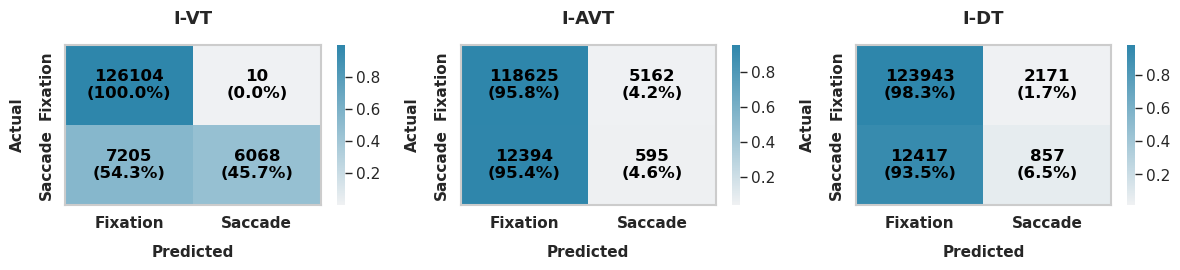

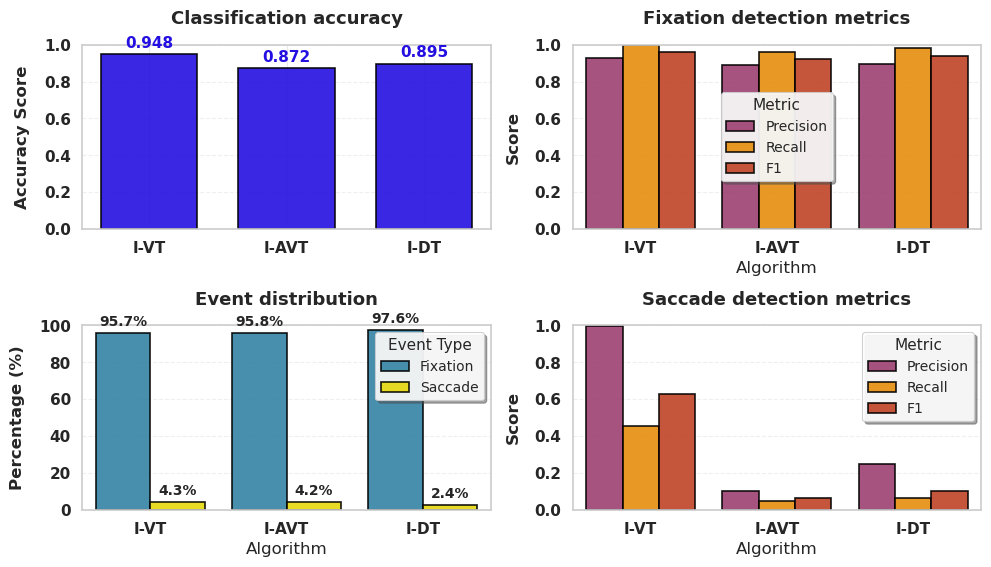


ALGORITHM PERFORMANCE SUMMARY
Algorithm  Accuracy  Precision (Fix)  Recall (Fix)  F1 (Fix)  Precision (Sac)  Recall (Sac)  F1 (Sac)  Fixation %  Saccade %
     I-VT    0.9482           0.9263        0.9999    0.9617           0.9977        0.4572    0.6270     95.7236     4.2764
    I-AVT    0.8716           0.8894        0.9583    0.9226           0.1012        0.0458    0.0631     95.7776     4.2224
     I-DT    0.8953           0.8931        0.9828    0.9358           0.2489        0.0646    0.1025     97.5792     2.4208


In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
warnings.filterwarnings("ignore", message="Passing `palette` without assigning `hue` is deprecated", category=FutureWarning)
warnings.filterwarnings("ignore", message="When grouping with a length-1 list-like, you will need to pass a length-1 tuple", category=FutureWarning)
warnings.filterwarnings("ignore", message="DataFrameGroupBy.apply operated on the grouping columns", category=FutureWarning)
def bold_ticks(ax, size=11, weight="bold"):
    ax.tick_params(axis='both', which='both', labelsize=size, width=1.5)
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight(weight)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight(weight)
def set_xylabels(ax, xlabel=None, ylabel=None, size=12, weight="bold"):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=size, fontweight=weight, labelpad=10)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=size, fontweight=weight, labelpad=10)

def set_title(ax, title, size=14, weight="bold", pad=15):
    ax.set_title(title, fontsize=size, fontweight=weight, pad=pad)
def analyze_all_algorithms(ground_truth, ivt_results, iavt_results, idt_results):
    sns.set_theme(style="whitegrid", context="paper")
    plt.rcParams.update({
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "font.family": "DejaVu Sans",  # Professional, readable font
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.8,
        "grid.alpha": 0.4
    })
    algorithms = {'I-VT': ivt_results, 'I-AVT': iavt_results, 'I-DT': idt_results}
    summary_df = pd.DataFrame(columns=[
        'Algorithm', 'Accuracy', 'Precision (Fix)', 'Recall (Fix)', 'F1 (Fix)',
        'Precision (Sac)', 'Recall (Sac)', 'F1 (Sac)', 'Fixation %', 'Saccade %'
    ])

    fig_cm, axs = plt.subplots(1, 3, figsize=(12, 3))

    cmap_cm = sns.light_palette("#2E86AB", as_cmap=True)
    
    for ax, (algo_name, results) in zip(axs, algorithms.items()):
        if 'classifier' not in results:
            ax.axis('off')
            ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=12, fontweight='bold')
            continue

        predictions = np.array([1 if cls == 'fixation' else 2 for cls in results['classifier']])
        L = min(len(ground_truth), len(predictions))
        y_true = ground_truth[:L]
        y_pred = predictions[:L]
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)
        annot = np.array([f"{count}\n({perc:.1%})" for count, perc in zip(cm.flatten(), cm_normalized.flatten())]).reshape(2, 2)
        sns.heatmap(
            cm_normalized, annot=annot, fmt='', cmap=cmap_cm, cbar=True, ax=ax,
            xticklabels=['Fixation', 'Saccade'], yticklabels=['Fixation', 'Saccade'],
            annot_kws={"size": 12, "weight": "bold", "color": "black"}#,
        )
        
        set_title(ax, f"{algo_name}", size=13)
        set_xylabels(ax, "Predicted", "Actual", size=11, weight="bold")
        bold_ticks(ax, size=11, weight="bold")
        
        for _, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

        report = classification_report(
            y_true, y_pred, target_names=['Fixation', 'Saccade'],
            labels=[1, 2], output_dict=True, zero_division=0
        )

        accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum() if cm.sum() > 0 else 0.0
        fix_count = int(np.sum(y_pred == 1))
        sac_count = int(np.sum(y_pred == 2))
        total = max(fix_count + sac_count, 1)
        fix_percent = 100.0 * fix_count / total
        sac_percent = 100.0 * sac_count / total

        summary_df = pd.concat([summary_df, pd.DataFrame([{
            'Algorithm': algo_name,
            'Accuracy': accuracy,
            'Precision (Fix)': report['Fixation']['precision'],
            'Recall (Fix)': report['Fixation']['recall'],
            'F1 (Fix)': report['Fixation']['f1-score'],
            'Precision (Sac)': report['Saccade']['precision'],
            'Recall (Sac)': report['Saccade']['recall'],
            'F1 (Sac)': report['Saccade']['f1-score'],
            'Fixation %': fix_percent,
            'Saccade %': sac_percent
        }])], ignore_index=True)

    plt.tight_layout(rect=[0, 0, 1, 0.93])  # Make room for suptitle
    plt.savefig("algorithm_confusion_matrices_Waldo.pdf", dpi=300, format='pdf', bbox_inches='tight')
    plt.show(fig_cm, "algorithm_confusion_matrices_Waldo")

    summary_df['Algorithm'] = pd.Categorical(summary_df['Algorithm'],
                                             categories=['I-VT', 'I-AVT', 'I-DT'],
                                             ordered=True)
    summary_df = summary_df.sort_values('Algorithm')

    #  color palette
    professional_palette = {
        'accuracy': "#240FE2",      
        'precision': '#A23B72',    
        'recall': '#F18F01',       
        'f1': '#C73E1D',           
        'fixation': '#2E86AB',     
        'saccade': "#F1E101"       
    }

    PAL_FIX = {"Precision": professional_palette['precision'], 
               "Recall": professional_palette['recall'], 
               "F1": professional_palette['f1']}
    
    PAL_SAC = {"Precision": professional_palette['precision'], 
               "Recall": professional_palette['recall'], 
               "F1": professional_palette['f1']}
    
    PAL_EVT = {"Fixation": professional_palette['fixation'], 
               "Saccade": professional_palette['saccade']}

    fig_metrics = plt.figure(figsize=(10, 6))
    ax1 = plt.subplot(2, 2, 1)
    x = np.arange(len(summary_df))
    vals = summary_df['Accuracy'].astype(float).to_numpy()
    
    bars = ax1.bar(x, vals, color=professional_palette['accuracy'], 
                   edgecolor='black', linewidth=1.2, alpha=0.9, width=0.7)
    ax1.set_xticks(x)
    ax1.set_xticklabels(summary_df['Algorithm'], fontweight='bold')
    set_title(ax1, 'Classification accuracy', size=13)
    set_xylabels(ax1, None, "Accuracy Score", size=12, weight="bold")
    ax1.set_ylim(0, 1)
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax1, size=11, weight="bold")
    for bar, v in zip(bars, vals):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02, 
                f"{v:.3f}", ha='center', va='bottom', 
                fontsize=11, fontweight="bold", color=professional_palette['accuracy'])

    ax2 = plt.subplot(2, 2, 2)
    fix_df = summary_df.melt(id_vars=['Algorithm'],
                             value_vars=['Precision (Fix)', 'Recall (Fix)', 'F1 (Fix)'],
                             var_name='Metric', value_name='Value')
    
    fix_df['Metric'] = fix_df['Metric'].str.replace(' (Fix)', '', regex=False)
    
    sns.barplot(x='Algorithm', y='Value', hue='Metric', data=fix_df,
                palette=PAL_FIX, edgecolor='black', linewidth=1.2,
                errorbar=None, ax=ax2, alpha=0.9, saturation=0.9)
    set_title(ax2, 'Fixation detection metrics', size=13)
    set_xylabels(ax2, None, "Score", size=12, weight="bold")
    ax2.set_ylim(0, 1)
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax2, size=11, weight="bold")
    ax2.legend(title='Metric', frameon=True, fancybox=True, 
              shadow=True, framealpha=0.9, loc='center', fontsize=10, title_fontsize=11)
    
    ax4 = plt.subplot(2, 2, 3)
    evt_df = summary_df.melt(id_vars=['Algorithm'],
                             value_vars=['Fixation %', 'Saccade %'],
                             var_name='Event Type', value_name='Percentage')
    
    evt_df['Event Type'] = evt_df['Event Type'].str.replace(' %', '', regex=False)
    
    sns.barplot(x='Algorithm', y='Percentage', hue='Event Type', data=evt_df,
                palette=PAL_EVT, edgecolor='black', linewidth=1.2,
                errorbar=None, ax=ax4, alpha=0.9, saturation=0.9)
    set_title(ax4, 'Event distribution', size=13)
    set_xylabels(ax4, None, "Percentage (%)", size=12, weight="bold")
    ax4.set_ylim(0, 100)
    ax4.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax4, size=11, weight="bold")
    ax4.legend(title='Event Type', frameon=True, fancybox=True, 
              shadow=True, framealpha=0.9, fontsize=10, title_fontsize=11)
    
    for container in ax4.containers:
        ax4.bar_label(container, fmt="%.1f%%", fontsize=10, fontweight="bold", padding=3)

    ax3 = plt.subplot(2, 2, 4)
    sac_df = summary_df.melt(id_vars=['Algorithm'],
                             value_vars=['Precision (Sac)', 'Recall (Sac)', 'F1 (Sac)'],
                             var_name='Metric', value_name='Value')
    
    sac_df['Metric'] = sac_df['Metric'].str.replace(' (Sac)', '', regex=False)
    
    sns.barplot(x='Algorithm', y='Value', hue='Metric', data=sac_df,
                palette=PAL_SAC, edgecolor='black', linewidth=1.2,
                errorbar=None, ax=ax3, alpha=0.9, saturation=0.9)
    set_title(ax3, 'Saccade detection metrics', size=13)
    set_xylabels(ax3, None, "Score", size=12, weight="bold")
    ax3.set_ylim(0, 1)
    ax3.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax3, size=11, weight="bold")
    ax3.legend(title='Metric', frameon=True, fancybox=True, 
              shadow=True, framealpha=0.9, fontsize=10, title_fontsize=11)


    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("algorithm_performance_metrics_Waldo.pdf", dpi=300, format='pdf', bbox_inches='tight')
    plt.show(fig_metrics, "algorithm_performance_metrics")

    print("\n" + "="*60)
    print("ALGORITHM PERFORMANCE SUMMARY")
    print("="*60)
    print(summary_df.round(4).to_string(index=False))
    print("="*60)

    return summary_df

# Usage (unchanged):
summary = analyze_all_algorithms(filtered_category_left, ivt_results, iavt_results, idt_results)



Analyzing Random Pixel
Loaded 15 files from ../extracted_randomPixel
Total samples: 91799

Processing noise levels...
  σ |  IVT_th |  IAVT_th |  IDT_xy |  IDT_dur
--------------------------------------------------
  1 |    7.89 |   7.4152 |   12.13 |    0.020
  2 |    9.99 |   8.7481 |   15.36 |    0.020
  5 |   14.37 |  13.0699 |  148.39 |    0.020
 10 |   22.88 |  18.9091 |   67.14 |    0.020
 30 |   73.40 |  24.0000 |  150.00 |    0.020
 40 |   97.83 |  24.0000 |  170.00 |    0.020
 50 |  122.25 |  22.0606 |  200.00 |    0.020

Analyzing Waldo
Loaded 16 files from ../extracted_waldo
Total samples: 142670

Processing noise levels...
  σ |  IVT_th |  IAVT_th |  IDT_xy |  IDT_dur
--------------------------------------------------
  1 |    7.17 |   6.6328 |    8.91 |    0.020
  2 |    9.31 |   8.2079 |   15.36 |    0.020
  5 |   14.30 |  12.2898 |   36.07 |    0.020
 10 |   23.84 |  21.8182 |   63.92 |    0.020
 30 |   71.62 |  24.0000 |  150.00 |    0.020
 40 |   95.40 |  24.0000 |  

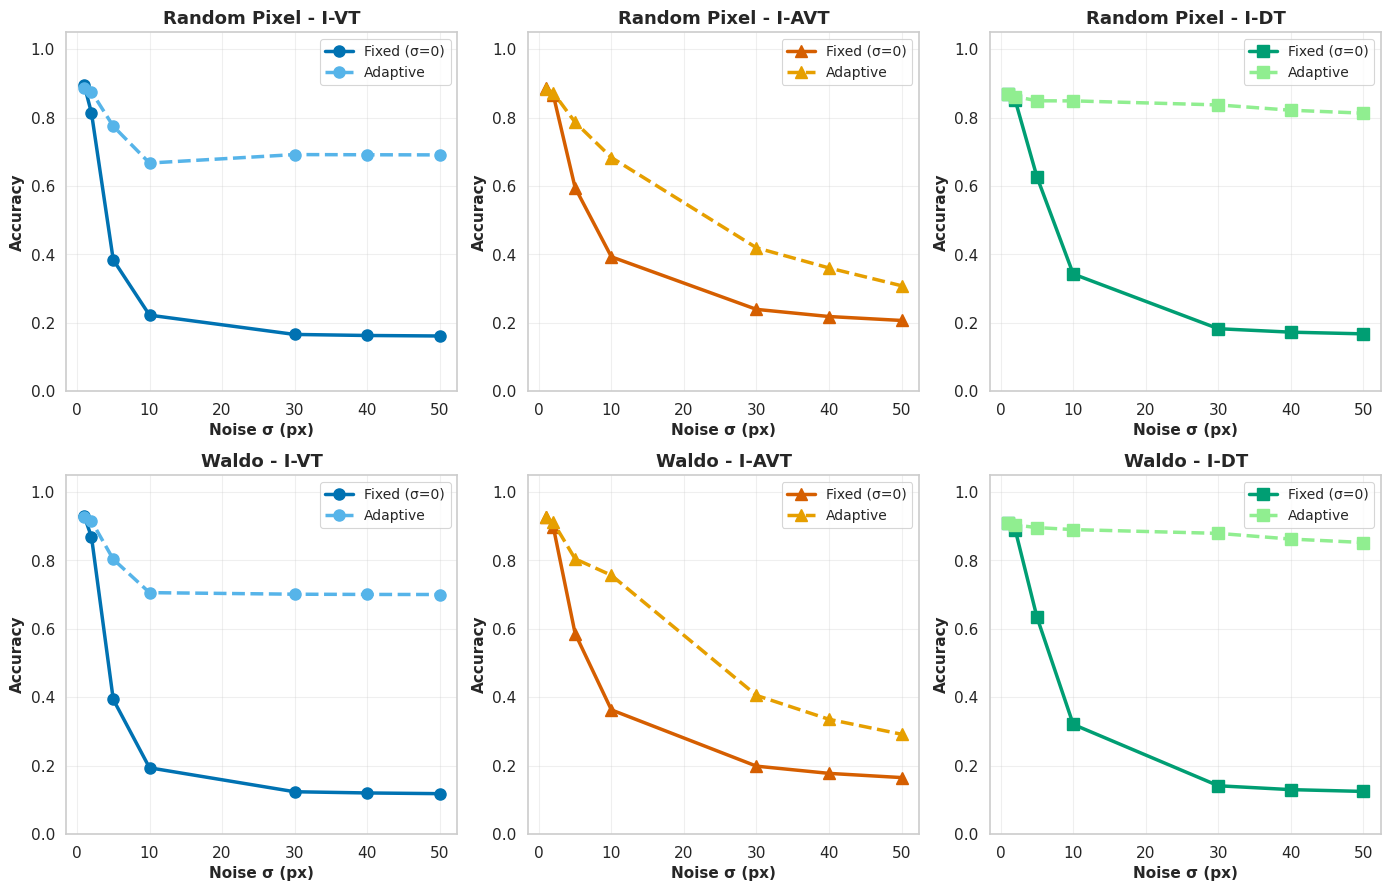


ACCURACY SUMMARY

--- Random Pixel ---

I-VT: σ | Fixed | Adaptive | Δ
     1 | 0.895 | 0.885    | -0.010
     2 | 0.813 | 0.876    | +0.062
     5 | 0.384 | 0.775    | +0.391
    10 | 0.222 | 0.667    | +0.445
    30 | 0.166 | 0.692    | +0.526
    40 | 0.163 | 0.691    | +0.529
    50 | 0.161 | 0.691    | +0.530

I-AVT: σ | Fixed | Adaptive | Δ
     1 | 0.887 | 0.885    | -0.002
     2 | 0.865 | 0.873    | +0.007
     5 | 0.595 | 0.786    | +0.191
    10 | 0.393 | 0.683    | +0.290
    30 | 0.239 | 0.419    | +0.180
    40 | 0.218 | 0.360    | +0.142
    50 | 0.207 | 0.308    | +0.102

I-DT: σ | Fixed | Adaptive | Δ
     1 | 0.869 | 0.868    | -0.001
     2 | 0.851 | 0.862    | +0.011
     5 | 0.626 | 0.849    | +0.223
    10 | 0.343 | 0.849    | +0.506
    30 | 0.183 | 0.837    | +0.655
    40 | 0.172 | 0.822    | +0.649
    50 | 0.167 | 0.813    | +0.645

--- Waldo ---

I-VT: σ | Fixed | Adaptive | Δ
     1 | 0.930 | 0.926    | -0.003
     2 | 0.869 | 0.915    | +0.046
     5 | 0.

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

NOISE_LEVELS = [1, 2, 5, 10, 30, 40, 50]
REMOVE_NAN_BEFORE = 500
OUTPUT_DIR = "outputs"
OPTIM_SAMPLE_SIZE = 30000

os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_eye_tracking_data(directory, skip_file_num=None):
    all_data = []
    file_count = 0
    
    for filename in sorted(os.listdir(directory)):
        if filename.endswith(".txt"):
            file_count += 1
            if skip_file_num is not None and file_count == skip_file_num:
                print(f"Skipping file {file_count} ({filename})")
                continue
            file_path = os.path.join(directory, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                numeric_data = [line.strip().split() for line in lines if not line.startswith("MSG")]
                if numeric_data:
                    df = pd.DataFrame(numeric_data)
                    df.columns = [f"col_{i}" for i in range(len(df.iloc[0]))]
                    df = df.apply(pd.to_numeric, errors='coerce')
                    all_data.append(df)
    
    print(f"Loaded {len(all_data)} files from {directory}")
    return all_data


def process_eye_data(all_data):
    filtered_x, filtered_y, filtered_time, filtered_category = [], [], [], []
    
    for i in range(len(all_data)):
        arr = np.swapaxes(np.array(all_data[i]), 0, 1)
        time_d, x_l, y_l = arr[0], arr[1], arr[2]
        x_r = arr[4] if arr.shape[0] > 4 else x_l
        y_r = arr[5] if arr.shape[0] > 5 else y_l
        cat = arr[8] if arr.shape[0] > 8 else np.ones_like(arr[0])
        
        valid = (~np.isnan(x_l) & ~np.isnan(y_l) & ~np.isnan(x_r) & ~np.isnan(y_r))
        new_valid = valid.copy()
        for j in range(1, REMOVE_NAN_BEFORE):
            if j < len(new_valid):
                new_valid[:-j] &= valid[j:]
        for j in range(1, REMOVE_NAN_BEFORE):
            if j < len(new_valid):
                new_valid[j:] &= new_valid[:-j]
        
        idx = np.where(new_valid)[0]
        filtered_x.append(x_l[idx])
        filtered_y.append(y_l[idx])
        filtered_time.append(time_d[idx])
        filtered_category.append(cat[idx])
    
    return {
        'x': np.concatenate(filtered_x),
        'y': np.concatenate(filtered_y),
        'time': np.concatenate(filtered_time),
        'category': np.concatenate(filtered_category)
    }

def compute_velocity(x, y, time):
    dx, dy = np.diff(x), np.diff(y)
    dt = np.diff(time)
    dt = np.where(dt == 0, 1e-6, dt)
    return np.sqrt(dx**2 + dy**2) / dt, dx, dy


def compute_angular_velocity(dx, dy):
    theta = np.full(len(dx) - 1, np.nan)
    for i in range(len(dx) - 1):
        n1 = np.sqrt(dx[i]**2 + dy[i]**2)
        n2 = np.sqrt(dx[i+1]**2 + dy[i+1]**2)
        if n1 > 0 and n2 > 0:
            dot = (dx[i]*dx[i+1] + dy[i]*dy[i+1]) / (n1 * n2)
            theta[i] = np.abs(np.arccos(np.clip(dot, -1, 1)))
    return theta


def compute_k_ratio_fast(classifier_array):
    n = len(classifier_array)
    if n == 0:
        return float('inf')
    P = np.sum(classifier_array == 2) / n
    if P == 0 or P == 1:
        return float('inf')
    p_ind = n * P * (1 - P)
    p_emp = np.sum(classifier_array[:-1] != classifier_array[1:])
    return p_emp / p_ind if p_ind > 0 else float('inf')


def compute_accuracy_fast(pred, gt):
    min_len = min(len(pred), len(gt))
    return np.sum(pred[:min_len] == gt[:min_len]) / min_len
def apply_ivt_fast(velo, threshold):
    return np.where(velo < threshold, 1, 2)
def apply_iavt_fast(velo_eff, threshold):
    return np.where(velo_eff < threshold, 1, 2)
def apply_idt_fast(x, y, time, xy_th, dur_th):
    n = len(x)
    classifier = np.zeros(n, dtype=np.int32)
    
    i = 0
    while i < n:
        start = i
        while i < n:
            window_x = x[start:i+1]
            window_y = y[start:i+1]
            disp_x = np.max(window_x) - np.min(window_x)
            disp_y = np.max(window_y) - np.min(window_y)
            if disp_x > xy_th or disp_y > xy_th:
                break
            i += 1
        
        if i > start:
            dur = time[i-1] - time[start] if i > start else 0
            if dur >= dur_th:
                classifier[start:i] = 1
            else:
                classifier[start:i] = 2
        
        if i < n:
            classifier[i] = 2
            i += 1
    
    classifier[classifier == 0] = 2
    return classifier
def optimize_ivt(velo):
    """Optimize I-VT using K-ratio (works well for velocity-based)."""
    thresholds = np.linspace(np.percentile(velo, 5), np.percentile(velo, 96), 100)
    best_k, best_th = float('inf'), thresholds[50]
    for t in thresholds:
        k = compute_k_ratio_fast(apply_ivt_fast(velo, t))
        if k < best_k:
            best_k, best_th = k, t
    return best_th
def optimize_iavt(velo_eff):
    """Optimize I-AVT using K-ratio."""
    finite = velo_eff[np.isfinite(velo_eff)]
    if len(finite) == 0:
        return 7.0
    thresholds = np.linspace(0, min(24, np.percentile(finite, 96)), 100)
    best_k, best_th = float('inf'), 7.0
    for t in thresholds:
        k = compute_k_ratio_fast(apply_iavt_fast(velo_eff, t))
        if k < best_k:
            best_k, best_th = k, t
    return best_th
def optimize_idt_kratio(x, y, time):
    """Optimize I-DT using K-ratio (for fixed threshold at σ=0)."""
    n = min(len(x), OPTIM_SAMPLE_SIZE)
    x_sub, y_sub, t_sub = x[:n], y[:n], time[:n]
    
    xy_values = np.linspace(10, 120, 12)
    dur_values = np.linspace(0.03, 0.25, 10)
    
    best_k, best_params = float('inf'), {'xy': 50, 'dur': 0.1}
    for xy in xy_values:
        for dur in dur_values:
            cls = apply_idt_fast(x_sub, y_sub, t_sub, xy, dur)
            k = compute_k_ratio_fast(cls)
            if k < best_k:
                best_k, best_params = k, {'xy': xy, 'dur': dur}
    
    return best_params
def optimize_idt_accuracy(x, y, time, gt, sigma):
    """
    Optimize I-DT using ACCURACY against ground truth.
    This allows adaptive threshold to actually improve with noise.
    """
    n = min(len(x), OPTIM_SAMPLE_SIZE)
    x_sub, y_sub, t_sub = x[:n], y[:n], time[:n]
    gt_sub = gt[:n]
    gt_sub = np.where((gt_sub == 1) | (gt_sub == "fixation"), 1, 2)
    
    # Search range scales with noise
    xy_min = max(5, sigma * 0.5)
    xy_max = max(150, 50 + sigma * 3)
    dur_min, dur_max = 0.02, 0.30
    
    xy_values = np.linspace(xy_min, xy_max, 15)
    dur_values = np.linspace(dur_min, dur_max, 10)
    
    best_acc, best_params = 0, {'xy': 50, 'dur': 0.1}
    for xy in xy_values:
        for dur in dur_values:
            cls = apply_idt_fast(x_sub, y_sub, t_sub, xy, dur)
            acc = compute_accuracy_fast(cls, gt_sub)
            if acc > best_acc:
                best_acc, best_params = acc, {'xy': xy, 'dur': dur}
    
    # Fine search
    xy_c, dur_c = best_params['xy'], best_params['dur']
    xy_step = (xy_max - xy_min) / 15
    dur_step = (dur_max - dur_min) / 10
    
    for xy in np.linspace(max(xy_min, xy_c - xy_step), min(xy_max, xy_c + xy_step), 7):
        for dur in np.linspace(max(dur_min, dur_c - dur_step), min(dur_max, dur_c + dur_step), 5):
            cls = apply_idt_fast(x_sub, y_sub, t_sub, xy, dur)
            acc = compute_accuracy_fast(cls, gt_sub)
            if acc > best_acc:
                best_acc, best_params = acc, {'xy': xy, 'dur': dur}
    
    return best_params
def evaluate(ground_truth, predictions):
    gt = np.where((ground_truth == 1) | (ground_truth == "fixation"), 1, 2)
    pred = predictions if isinstance(predictions, np.ndarray) else np.array(predictions)
    
    min_len = min(len(gt), len(pred))
    gt, pred = gt[:min_len], pred[:min_len]
    
    cm = confusion_matrix(gt, pred, labels=[1, 2])
    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum() if cm.sum() > 0 else 0
    
    report = classification_report(gt, pred, target_names=['Fixation', 'Saccade'],
                                   labels=[1, 2], output_dict=True, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision_fix': report['Fixation']['precision'],
        'recall_fix': report['Fixation']['recall'],
        'f1_fix': report['Fixation']['f1-score'],
        'precision_sac': report['Saccade']['precision'],
        'recall_sac': report['Saccade']['recall'],
        'f1_sac': report['Saccade']['f1-score'],
        'fix_count': int(np.sum(pred == 1)),
        'sac_count': int(np.sum(pred == 2))
    }

def add_noise(x, y, sigma):
    if sigma == 0:
        return x.copy(), y.copy()
    return x + np.random.normal(0, sigma, len(x)), y + np.random.normal(0, sigma, len(y))
def analyze_task(directory, task_name, skip_file=None):
    print(f"\n{'='*60}")
    print(f"Analyzing {task_name}")
    print(f"{'='*60}")
    
    all_data = load_eye_tracking_data(directory, skip_file)
    data = process_eye_data(all_data)
    print(f"Total samples: {len(data['x'])}")
    
    x, y, time, category = data['x'], data['y'], data['time'], data['category']
    velo_clean, dx_clean, dy_clean = compute_velocity(x, y, time)
    theta_clean = compute_angular_velocity(dx_clean, dy_clean)
    valid_theta = ~np.isnan(theta_clean)
    velo_eff_clean = np.abs(velo_clean[:-1][valid_theta] * np.cos(theta_clean[valid_theta]))
    
    fixed_ivt = optimize_ivt(velo_clean)
    fixed_iavt = optimize_iavt(velo_eff_clean)
    fixed_idt = optimize_idt_kratio(x, y, time)
    

    
    results = {
        'I-VT': {'fixed': [], 'adaptive': [], 'adaptive_th': []},
        'I-AVT': {'fixed': [], 'adaptive': [], 'adaptive_th': []},
        'I-DT': {'fixed': [], 'adaptive': [], 'adaptive_th': []}
    }
    
    print("\nProcessing noise levels...")
    print(f"{'σ':>3} | {'IVT_th':>7} | {'IAVT_th':>8} | {'IDT_xy':>7} | {'IDT_dur':>8}")
    print("-" * 50)
    
    for sigma in NOISE_LEVELS:
        np.random.seed(42)
        noisy_x, noisy_y = add_noise(x, y, sigma)
        
        velo, dx, dy = compute_velocity(noisy_x, noisy_y, time)
        theta = compute_angular_velocity(dx, dy)
        valid = ~np.isnan(theta)
        velo_eff = np.abs(velo[:-1][valid] * np.cos(theta[valid]))
        
        results['I-VT']['fixed'].append(evaluate(category[:-1], apply_ivt_fast(velo, fixed_ivt)))
        adapt_ivt = optimize_ivt(velo)
        results['I-VT']['adaptive'].append(evaluate(category[:-1], apply_ivt_fast(velo, adapt_ivt)))
        results['I-VT']['adaptive_th'].append(adapt_ivt)
        
        # I-AVT (K-ratio optimization)
        cat_iavt = category[1:-1][valid]
        results['I-AVT']['fixed'].append(evaluate(cat_iavt, apply_iavt_fast(velo_eff, fixed_iavt)))
        adapt_iavt = optimize_iavt(velo_eff)
        results['I-AVT']['adaptive'].append(evaluate(cat_iavt, apply_iavt_fast(velo_eff, adapt_iavt)))
        results['I-AVT']['adaptive_th'].append(adapt_iavt)
        
        # I-DT: Fixed uses K-ratio threshold, Adaptive uses ACCURACY optimization
        results['I-DT']['fixed'].append(evaluate(category, apply_idt_fast(noisy_x, noisy_y, time, 
                                                                          fixed_idt['xy'], fixed_idt['dur'])))
        adapt_idt = optimize_idt_accuracy(noisy_x, noisy_y, time, category, sigma)
        results['I-DT']['adaptive'].append(evaluate(category, apply_idt_fast(noisy_x, noisy_y, time,
                                                                              adapt_idt['xy'], adapt_idt['dur'])))
        results['I-DT']['adaptive_th'].append(adapt_idt)
        
        print(f"{sigma:3} | {adapt_ivt:7.2f} | {adapt_iavt:8.4f} | {adapt_idt['xy']:7.2f} | {adapt_idt['dur']:8.3f}")
    
    return results, {'ivt': fixed_ivt, 'iavt': fixed_iavt, 'idt': fixed_idt}
def generate_latex_table(results, noise_levels, algo, task):
    lines = [
        f"\\begin{{table}}[htb]",
        f"\\centering",
        f"\\caption{{{task} – {algo}: Fixed vs Adaptive threshold accuracy.}}",
        f"\\label{{tab:{task.lower().replace(' ', '_')}_{algo.lower().replace('-', '')}}}",
        f"\\begin{{tabular}}{{lcccccc}}",
        f"\\toprule",
        f"$\\sigma$ & Acc (Fix) & Acc (Adp) & F1-F (Fix) & F1-F (Adp) & F1-S (Fix) & F1-S (Adp) \\\\",
        f"\\midrule"
    ]
    
    for i, sigma in enumerate(noise_levels):
        f, a = results['fixed'][i], results['adaptive'][i]
        lines.append(f"{sigma} & {f['accuracy']:.3f} & {a['accuracy']:.3f} & "
                    f"{f['f1_fix']:.3f} & {a['f1_fix']:.3f} & "
                    f"{f['f1_sac']:.3f} & {a['f1_sac']:.3f} \\\\")
    
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}", ""])
    return "\n".join(lines)
def plot_comparison(results_rp, results_waldo, noise_levels):
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    
    colors = {'fixed': {'I-VT': '#0072B2', 'I-AVT': '#D55E00', 'I-DT': '#009E73'},
              'adaptive': {'I-VT': '#56B4E9', 'I-AVT': '#E69F00', 'I-DT': '#90EE90'}}
    markers = {'I-VT': 'o', 'I-AVT': '^', 'I-DT': 's'}
    
    tasks = [('Random Pixel', results_rp), ('Waldo', results_waldo)]
    algos = ['I-VT', 'I-AVT', 'I-DT']
    
    for row, (task, results) in enumerate(tasks):
        for col, algo in enumerate(algos):
            ax = axes[row, col]
            fixed_acc = [r['accuracy'] for r in results[algo]['fixed']]
            adapt_acc = [r['accuracy'] for r in results[algo]['adaptive']]
            
            ax.plot(noise_levels, fixed_acc, marker=markers[algo], linewidth=2.5,
                    color=colors['fixed'][algo], label='Fixed (σ=0)', markersize=8)
            ax.plot(noise_levels, adapt_acc, marker=markers[algo], linewidth=2.5,
                    color=colors['adaptive'][algo], label='Adaptive', markersize=8, linestyle='--')
            
            ax.set_xlabel('Noise σ (px)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
            ax.set_title(f'{task} - {algo}', fontsize=13, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fixed_vs_adaptive_accuracy.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

def save_results_to_csv(results_rp, results_waldo, noise_levels):
    """Save all metrics (accuracy, precision, recall, F1) to CSV files."""
    
    rows = []
    for task, results in [('Random Pixel', results_rp), ('Waldo', results_waldo)]:
        for algo in ['I-VT', 'I-AVT', 'I-DT']:
            for i, sigma in enumerate(noise_levels):
                # Fixed threshold metrics
                f = results[algo]['fixed'][i]
                rows.append({
                    'task': task,
                    'algorithm': algo,
                    'sigma': sigma,
                    'threshold_type': 'fixed',
                    'accuracy': f['accuracy'],
                    'precision_fix': f['precision_fix'],
                    'recall_fix': f['recall_fix'],
                    'f1_fix': f['f1_fix'],
                    'precision_sac': f['precision_sac'],
                    'recall_sac': f['recall_sac'],
                    'f1_sac': f['f1_sac'],
                    'fix_count': f['fix_count'],
                    'sac_count': f['sac_count']
                })
                
                # Adaptive threshold metrics
                a = results[algo]['adaptive'][i]
                rows.append({
                    'task': task,
                    'algorithm': algo,
                    'sigma': sigma,
                    'threshold_type': 'adaptive',
                    'accuracy': a['accuracy'],
                    'precision_fix': a['precision_fix'],
                    'recall_fix': a['recall_fix'],
                    'f1_fix': a['f1_fix'],
                    'precision_sac': a['precision_sac'],
                    'recall_sac': a['recall_sac'],
                    'f1_sac': a['f1_sac'],
                    'fix_count': a['fix_count'],
                    'sac_count': a['sac_count']
                })
    

    df_long = pd.DataFrame(rows)
    df_long.to_csv(os.path.join(OUTPUT_DIR, 'noise_analysis_all_metrics.csv'), index=False)
    print(f"\nSaved: {OUTPUT_DIR}/noise_analysis_all_metrics.csv")
    
    # Save wide format (easier for plotting)
    wide_rows = []
    for task, results in [('Random Pixel', results_rp), ('Waldo', results_waldo)]:
        for i, sigma in enumerate(noise_levels):
            row = {'task': task, 'sigma': sigma}
            for algo in ['I-VT', 'I-AVT', 'I-DT']:
                algo_key = algo.replace('-', '')
                f = results[algo]['fixed'][i]
                a = results[algo]['adaptive'][i]
                
                # Fixed metrics
                row[f'{algo_key}_fixed_accuracy'] = f['accuracy']
                row[f'{algo_key}_fixed_precision_fix'] = f['precision_fix']
                row[f'{algo_key}_fixed_recall_fix'] = f['recall_fix']
                row[f'{algo_key}_fixed_f1_fix'] = f['f1_fix']
                row[f'{algo_key}_fixed_precision_sac'] = f['precision_sac']
                row[f'{algo_key}_fixed_recall_sac'] = f['recall_sac']
                row[f'{algo_key}_fixed_f1_sac'] = f['f1_sac']
                
                # Adaptive metrics
                row[f'{algo_key}_adaptive_accuracy'] = a['accuracy']
                row[f'{algo_key}_adaptive_precision_fix'] = a['precision_fix']
                row[f'{algo_key}_adaptive_recall_fix'] = a['recall_fix']
                row[f'{algo_key}_adaptive_f1_fix'] = a['f1_fix']
                row[f'{algo_key}_adaptive_precision_sac'] = a['precision_sac']
                row[f'{algo_key}_adaptive_recall_sac'] = a['recall_sac']
                row[f'{algo_key}_adaptive_f1_sac'] = a['f1_sac']
            
            wide_rows.append(row)
    
    df_wide = pd.DataFrame(wide_rows)
    df_wide.to_csv(os.path.join(OUTPUT_DIR, 'noise_analysis_wide.csv'), index=False)
    print(f"Saved: {OUTPUT_DIR}/noise_analysis_wide.csv")
    
    return df_long, df_wide

def main():
    results_rp, _ = analyze_task("../extracted_randomPixel", "Random Pixel", skip_file=16)
    results_waldo, _ = analyze_task("../extracted_waldo", "Waldo")
    
    
    all_tables = ""
    for task, results in [("Random Pixel", results_rp), ("Waldo", results_waldo)]:
        for algo in ['I-VT', 'I-AVT', 'I-DT']:
            table = generate_latex_table(results[algo], NOISE_LEVELS, algo, task)
            all_tables += table + "\n\n"
            print(f"\n{task} - {algo}:\n{table}")
    
    with open(os.path.join(OUTPUT_DIR, "noise_analysis_tables.tex"), 'w') as f:
        f.write(all_tables)
    
    # Save all metrics to CSV
    save_results_to_csv(results_rp, results_waldo, NOISE_LEVELS)
    
    plot_comparison(results_rp, results_waldo, NOISE_LEVELS)
    
    print("\n" + "="*60)
    print("ACCURACY SUMMARY")
    print("="*60)
    for task, results in [("Random Pixel", results_rp), ("Waldo", results_waldo)]:
        print(f"\n--- {task} ---")
        for algo in ['I-VT', 'I-AVT', 'I-DT']:
            print(f"\n{algo}: σ | Fixed | Adaptive | Δ")
            for i, sigma in enumerate(NOISE_LEVELS):
                f_acc = results[algo]['fixed'][i]['accuracy']
                a_acc = results[algo]['adaptive'][i]['accuracy']
                print(f"  {sigma:4} | {f_acc:.3f} | {a_acc:.3f}    | {a_acc-f_acc:+.3f}")


if __name__ == "__main__":
    main()